--- 1. MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---


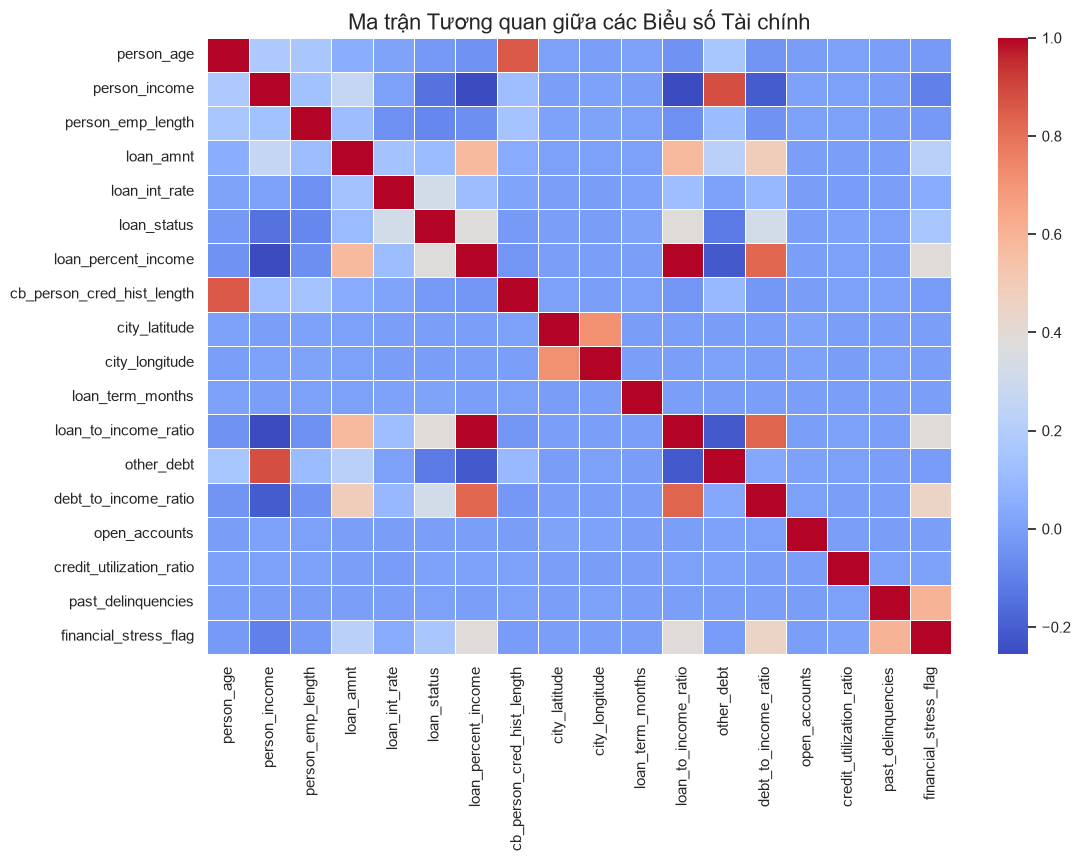

Các yếu tố tương quan mạnh nhất với loan_status:
loan_status             1.000000
loan_to_income_ratio    0.385873
loan_percent_income     0.379366
debt_to_income_ratio    0.321503
loan_int_rate           0.319360
Name: loan_status, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv('data/credit_risk_data_feature_extracted.csv')

print("--- 1. MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---")
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận Tương quan giữa các Biểu số Tài chính', fontsize=16)
plt.show()

print("Các yếu tố tương quan mạnh nhất với loan_status:")
print(corr_matrix['loan_status'].sort_values(ascending=False).head(5))

In [2]:
import numpy as np

print("--- KIỂM TRA ĐA CỘNG TUYẾN (MULTICOLLINEARITY) ---")

X = df.drop(columns=['loan_status'])

numeric_features = X.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_features.corr().abs()

# 3. Lấy tam giác trên (Upper Triangle) của ma trận
# Việc này giúp tránh việc thuật toán quét trùng lặp (Cột A tương quan cột B, rồi lại báo Cột B tương quan cột A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Xác định ngưỡng tương quan (Threshold)
# Trong ngành ngân hàng, mức 0.75 hoặc 0.8 thường được chọn làm ranh giới
threshold = 0.75

# Tìm các cột có ít nhất 1 giá trị tương quan lớn hơn threshold
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"Ngưỡng cắt (Threshold): {threshold}")
if len(to_drop) > 0:
    print(f"Các Feature thừa cần loại bỏ: {to_drop}")
    
    # In ra cụ thể nó tương quan với ai để sếp/bạn hiểu lý do
    for col in to_drop:
        # Tìm cột mà nó tương quan cao nhất
        correlated_with = upper_tri[col][upper_tri[col] > threshold].index.tolist()
        print(f" -> Cột '{col}' có tương quan rất cao với {correlated_with}")
        
    # 5. Thực hiện Drop
    df_optimized = df.drop(columns=to_drop)
    print("\nĐã hoàn tất việc drop! Dữ liệu (df_optimized) hiện tại đã tối ưu và không còn bị nhiễu.")
else:
    print("Tuyệt vời! Không có feature nào bị đa cộng tuyến. Dữ liệu đã sẵn sàng.")
    df_optimized = df.copy()

# Bạn có thể lưu lại file để dùng cho Bước 4 (Chuẩn hóa & Chạy Model)
df_optimized.to_csv('data/credit_risk_data_optimized.csv', index=False)

--- KIỂM TRA ĐA CỘNG TUYẾN (MULTICOLLINEARITY) ---
Ngưỡng cắt (Threshold): 0.75
Các Feature thừa cần loại bỏ: ['cb_person_cred_hist_length', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio']
 -> Cột 'cb_person_cred_hist_length' có tương quan rất cao với ['person_age']
 -> Cột 'loan_to_income_ratio' có tương quan rất cao với ['loan_percent_income']
 -> Cột 'other_debt' có tương quan rất cao với ['person_income']
 -> Cột 'debt_to_income_ratio' có tương quan rất cao với ['loan_percent_income', 'loan_to_income_ratio']

Đã hoàn tất việc drop! Dữ liệu (df_optimized) hiện tại đã tối ưu và không còn bị nhiễu.


In [3]:
df_optimized.describe(include='all').T
df_optimized.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,employment_type,loan_term_months,open_accounts,credit_utilization_ratio,past_delinquencies,age_group_raw,age_group,credit_history_group_raw,credit_history_group,financial_stress_flag
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,Self-employed,36,14,0.495557,0,"(19.999, 23.0]",20-23,"(1.999, 3.0]",Ngắn,1
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,Full-time,36,10,0.585436,3,"(19.999, 23.0]",20-23,"(1.999, 3.0]",Ngắn,1
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,Full-time,36,14,0.750732,0,"(23.0, 26.0]",23-26,"(1.999, 3.0]",Ngắn,1
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,Part-time,12,15,0.379333,0,"(19.999, 23.0]",20-23,"(1.999, 3.0]",Ngắn,1
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,Part-time,36,4,0.228103,0,"(23.0, 26.0]",23-26,"(3.0, 4.0]",Trung bình,1



--- 2. PHÂN TÍCH TỶ LỆ NỢ XẤU THEO ĐẶC ĐIỂM KHÁCH HÀNG ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2564\450301941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_risk.index, y=intent_risk.values, ax=axes[0], palette='Reds_r')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2564\450301941.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_risk.index, y=home_risk.values, ax=axes[1], palette='Oranges_r')


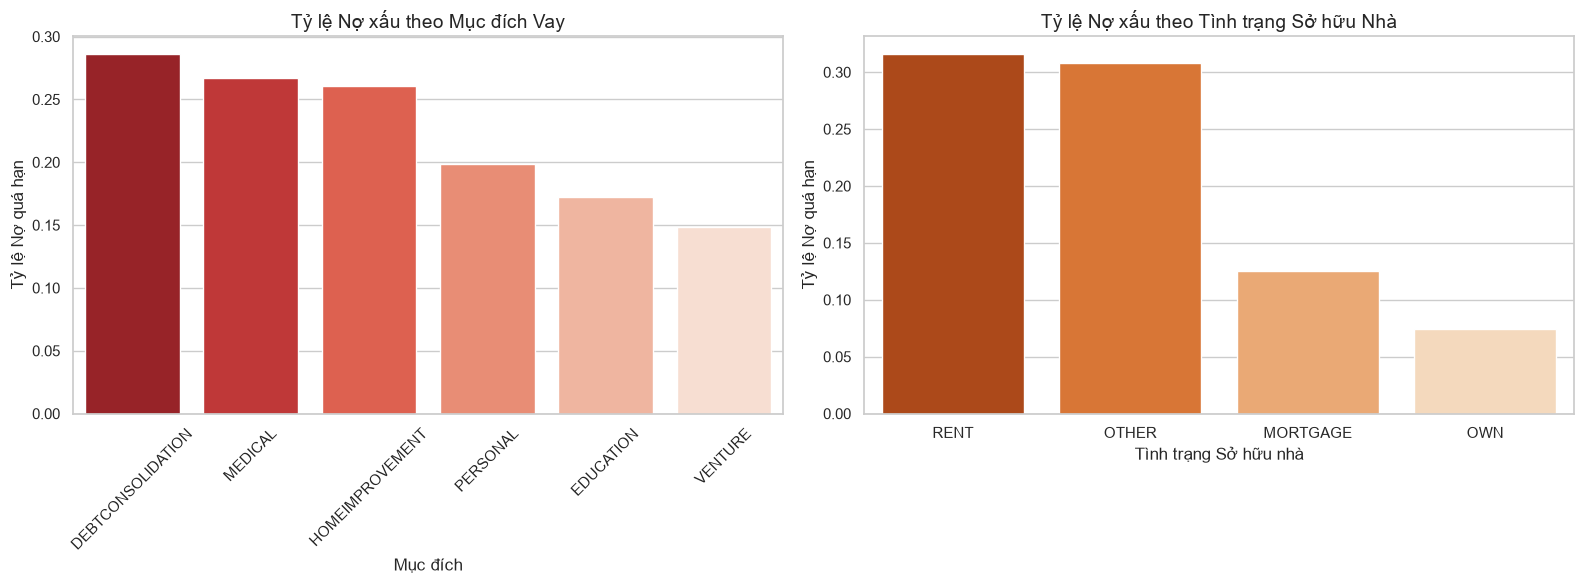

In [4]:
print("\n--- 2. PHÂN TÍCH TỶ LỆ NỢ XẤU THEO ĐẶC ĐIỂM KHÁCH HÀNG ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tỷ lệ nợ xấu theo Mục đích vay (loan_intent)
# Tính tỷ lệ trung bình của loan_status (1 = Nợ xấu, nên mean() chính là tỷ lệ %)
intent_risk = df_optimized.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
sns.barplot(x=intent_risk.index, y=intent_risk.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('Tỷ lệ Nợ xấu theo Mục đích Vay', fontsize=14)
axes[0].set_ylabel('Tỷ lệ Nợ quá hạn')
axes[0].set_xlabel('Mục đích')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ 2: Tỷ lệ nợ xấu theo Tình trạng Sở hữu nhà (person_home_ownership)
home_risk = df_optimized.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)
sns.barplot(x=home_risk.index, y=home_risk.values, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Tỷ lệ Nợ xấu theo Tình trạng Sở hữu Nhà', fontsize=14)
axes[1].set_ylabel('Tỷ lệ Nợ quá hạn')
axes[1].set_xlabel('Tình trạng Sở hữu nhà')

plt.tight_layout()
plt.show()


--- 3. KIỂM CHỨNG HIỆU QUẢ CỦA CỜ CẢNH BÁO SỚM ---


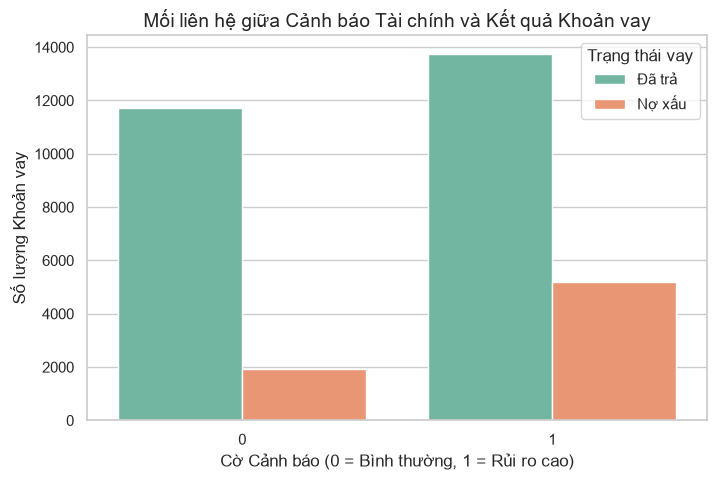

- Tỷ lệ nợ xấu ở nhóm bị GẮN CỜ (DTI > 40% hoặc từng trễ hạn): 27.38%
- Tỷ lệ nợ xấu ở nhóm BÌNH THƯỜNG: 14.09%


In [5]:
print("\n--- 3. KIỂM CHỨNG HIỆU QUẢ CỦA CỜ CẢNH BÁO SỚM ---")

# Vẽ biểu đồ đếm số lượng Nợ xấu chia theo Cờ cảnh báo
plt.figure(figsize=(8, 5))
sns.countplot(data=df_optimized, x='financial_stress_flag', hue='loan_status', palette='Set2')
plt.title('Mối liên hệ giữa Cảnh báo Tài chính và Kết quả Khoản vay', fontsize=14)
plt.xlabel('Cờ Cảnh báo (0 = Bình thường, 1 = Rủi ro cao)')
plt.ylabel('Số lượng Khoản vay')
plt.legend(title='Trạng thái vay', labels=['Đã trả', 'Nợ xấu'])
plt.show()

# Tính toán con số cụ thể
flagged_default_rate = df_optimized[df_optimized['financial_stress_flag'] == 1]['loan_status'].mean() * 100
normal_default_rate = df_optimized[df_optimized['financial_stress_flag'] == 0]['loan_status'].mean() * 100

print(f"- Tỷ lệ nợ xấu ở nhóm bị GẮN CỜ (DTI > 40% hoặc từng trễ hạn): {flagged_default_rate:.2f}%")
print(f"- Tỷ lệ nợ xấu ở nhóm BÌNH THƯỜNG: {normal_default_rate:.2f}%")